# Model Training

## Objective

The objective of this notebook is to train a baseline Logistic Regression model using the feature-engineered dataset.

Unlike previous notebooks, preprocessing and model training are integrated into a Scikit-Learn Pipeline to ensure a reusable and production-ready workflow.

The notebook includes:

- Data preparation
- Automated preprocessing
- Model training
- Cross-validation
- Performance evaluation
- Model interpretation
- Pipeline serialization

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


In [3]:
X = df.drop(columns=["Churn", "Churn_Binary","customerID"])

y = df["Churn_Binary"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 24)
Target: (7032,)


## Data Preparation

The target variable is separated from the predictor variables.

The customer identifier is removed because it does not contain predictive information.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio.

Stratified sampling is used to preserve the original churn distribution in both datasets.

In [5]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices"
]

In [6]:
binary_features = [
    "SeniorCitizen",
    "HasFamily"
]

In [7]:
nominal_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [8]:
ordinal_features = [
    "TenureGroup",
    "SpendingGroup"
]

## Feature Categorization

Features are categorized based on their statistical properties rather than simply by data type.

- Continuous numerical features are standardized.
- Binary features are passed unchanged.
- Nominal categorical features are one-hot encoded.
- Ordinal categorical features are ordinal encoded to preserve their natural ordering.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            StandardScaler(),
            continuous_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["New","Growing","Established","Loyal"],
                    ["Low","Medium","High"]
                ]
            ),
            ordinal_features
        )
    ]
)

In [19]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HasFamily','TenureGroup', 'SpendingGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [18]:
print("Continuous:", continuous_features)
print()

print("Binary:", binary_features)
print()

print("Nominal:", nominal_features)
print()

print("Ordinal:", ordinal_features)

Continuous: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices']

Binary: ['SeniorCitizen', 'HasFamily']

Nominal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Ordinal: ['TenureGroup', 'SpendingGroup']


baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Machine Learning Pipeline

## Objective

A machine learning pipeline combines preprocessing and model training into a single reusable workflow.

Rather than manually preprocessing the data before every prediction, the pipeline automatically performs all required transformations and then trains the machine learning model.

This approach:

- Prevents data leakage
- Simplifies deployment
- Ensures consistent preprocessing
- Follows industry best practices

In [20]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [21]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [22]:
from sklearn import set_config

set_config(display="diagram")

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

# Baseline Model Training

The complete pipeline is fitted using the training dataset.

During training, the pipeline automatically:

1. Standardizes continuous numerical features.
2. Passes binary features unchanged.
3. One-Hot Encodes nominal categorical variables.
4. Ordinal Encodes ordered categorical variables.
5. Trains the Logistic Regression classifier.

The fitted pipeline can later be used directly for prediction on unseen customer data.

In [23]:
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HasFamily','TenureGroup', 'SpendingGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

# Cross Validation

## Objective

Model performance obtained from a single train-test split may vary depending on the specific samples selected.

To obtain a more reliable estimate of model performance, Stratified K-Fold Cross Validation is performed.

Stratification preserves the original class distribution within every fold, making the evaluation more representative of real-world performance.

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [29]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for metric in metrics:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metric
    )

    cv_results[metric] = scores

In [30]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean": [
        cv_results["accuracy"].mean(),
        cv_results["precision"].mean(),
        cv_results["recall"].mean(),
        cv_results["f1"].mean(),
        cv_results["roc_auc"].mean()
    ],
    "Std": [
        cv_results["accuracy"].std(),
        cv_results["precision"].std(),
        cv_results["recall"].std(),
        cv_results["f1"].std(),
        cv_results["roc_auc"].std()
    ]
})

cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std
0,Accuracy,0.8020,0.0098
1,Precision,0.6524,0.0246
2,Recall,0.5465,0.0210
3,F1-Score,0.5946,0.0199
4,ROC-AUC,0.8455,0.0051


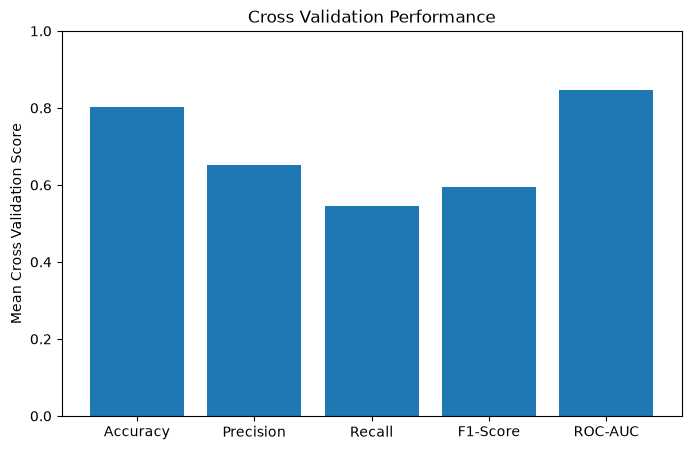

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_summary["Metric"],
    cv_summary["Mean"]
)

plt.ylim(0, 1)

plt.ylabel("Mean Cross Validation Score")
plt.title("Cross Validation Performance")

plt.show()

## Cross Validation Summary

The Logistic Regression baseline model demonstrates stable performance across all five folds.

Key observations:

- Accuracy: **80.20%**
- Precision: **65.24%**
- Recall: **54.65%**
- F1-Score: **59.46%**
- ROC-AUC: **84.55%**

The low standard deviation across all metrics indicates that the model generalizes consistently across different subsets of the training data.

Although the model achieves strong overall accuracy and ROC-AUC, the recall score suggests that nearly half of the actual churning customers are not detected.

Future model improvements will focus on increasing recall while maintaining acceptable precision.

# Model Evaluation

## Objective

After training the baseline model, its performance is evaluated on the unseen test dataset.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Together, these metrics provide a comprehensive understanding of the model's predictive performance.

In [32]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]

In [33]:
test_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

test_summary = pd.DataFrame(
    test_results.items(),
    columns=["Metric", "Score"]
)

test_summary["Score"] = test_summary["Score"].round(4)

test_summary

,Metric,Score
0,Accuracy,0.8010
1,Precision,0.6442
2,Recall,0.5615
3,F1-Score,0.6000
4,ROC-AUC,0.8350


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



## Classification Report

The classification report summarizes precision, recall, F1-score, and support for each class.

This provides a more detailed evaluation than overall accuracy, especially for imbalanced classification problems such as customer churn prediction.

# 12. Confusion Matrix

## Objective

The confusion matrix illustrates how many predictions were:

- Correctly classified as churn
- Correctly classified as non-churn
- Incorrectly classified

This helps identify the types of prediction errors made by the model.

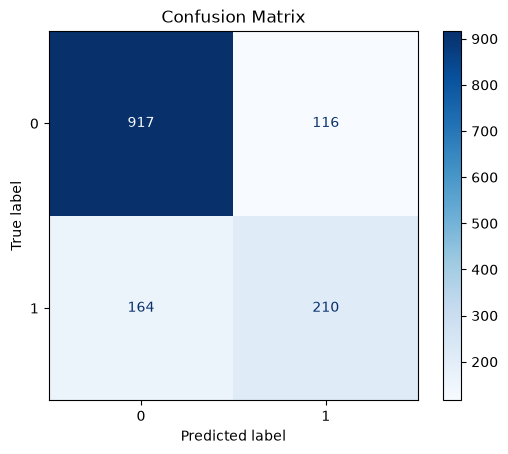

In [35]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# 13. ROC Curve

The ROC curve evaluates the model across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) measures how well the model distinguishes between churned and non-churned customers.

Higher values indicate better discrimination.

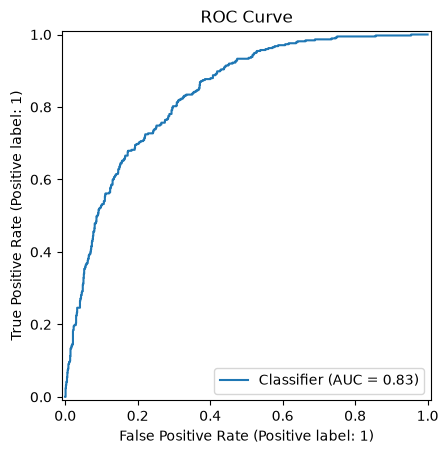

In [36]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

In [37]:
comparison = pd.DataFrame({
    "Metric": cv_summary["Metric"],
    "Cross Validation": cv_summary["Mean"],
    "Test": test_summary["Score"]
})

comparison = comparison.round(4)

comparison

,Metric,Cross Validation,Test
0,Accuracy,0.8020,0.8010
1,Precision,0.6524,0.6442
2,Recall,0.5465,0.5615
3,F1-Score,0.5946,0.6000
4,ROC-AUC,0.8455,0.8350


## Model Performance Comparison

The cross-validation results are compared with the test set performance.

If the scores are similar, the model is likely to generalize well.

Large differences between cross-validation and test performance may indicate overfitting or underfitting.

## Business Interpretation

The baseline Logistic Regression model achieves an accuracy of **80.1%** on the unseen test dataset.

The similarity between cross-validation and test performance indicates that the model generalizes well and is not overfitting the training data.

The model demonstrates strong ability to identify customers who remain with the company.

However, recall for the churn class is approximately **56%**, indicating that around 44% of customers who eventually churn are not detected.

Since customer churn prediction focuses on identifying customers at risk of leaving, improving recall will be an important objective during future model optimization.

In [38]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [39]:
coefficients = pipeline.named_steps[
    "classifier"
].coef_[0]

In [40]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [41]:
importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance.head(20)

,Feature,Coefficient
39,nominal__Contract_Month-to-month,0.655605
19,nominal__InternetService_Fiber optic,0.617817
2,continuous__TotalCharges,0.565822
21,nominal__OnlineSecurity_No,0.214454
4,continuous__TotalServices,0.212936
46,nominal__PaymentMethod_Electronic check,0.194359
30,nominal__TechSupport_No,0.194311
5,binary__SeniorCitizen,0.190397
35,nominal__StreamingTV_Yes,0.160008
38,nominal__StreamingMovies_Yes,0.144813


In [43]:
importance.tail(20)

,Feature,Coefficient
33,nominal__StreamingTV_No,-0.176574
49,ordinal__SpendingGroup,-0.185666
44,nominal__PaymentMethod_Bank transfer (automatic),-0.192801
14,nominal__PhoneService_Yes,-0.208279
32,nominal__TechSupport_Yes,-0.210878
23,nominal__OnlineSecurity_Yes,-0.231020
25,nominal__OnlineBackup_No internet service,-0.237776
28,nominal__DeviceProtection_No internet service,-0.237776
34,nominal__StreamingTV_No internet service,-0.237776
31,nominal__TechSupport_No internet service,-0.237776


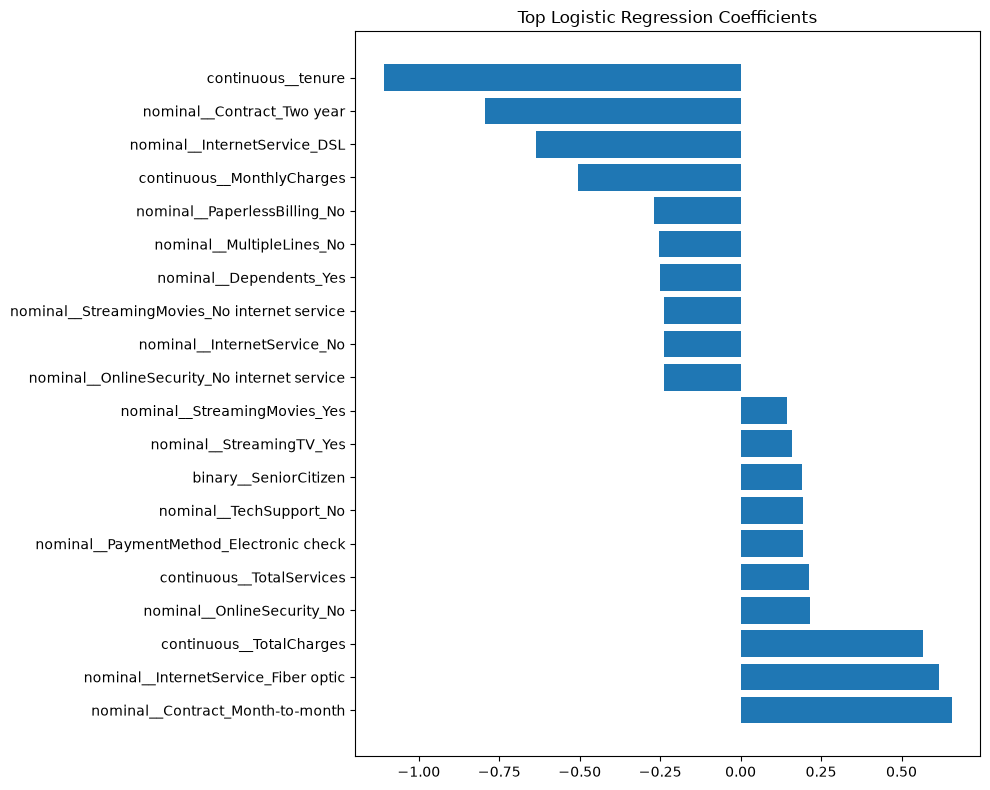

In [42]:
top20 = pd.concat([
    importance.head(10),
    importance.tail(10)
])

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Coefficient"]
)

plt.title("Top Logistic Regression Coefficients")

plt.tight_layout()

plt.show()

## Feature Importance Interpretation

Logistic Regression coefficients provide insight into how each feature influences the probability of customer churn.

### Features Associated with Higher Churn Risk

- Month-to-month contracts
- Fiber optic internet service
- Higher total charges
- No online security
- No technical support
- Electronic check payment method

### Features Associated with Lower Churn Risk

- Longer customer tenure
- Two-year contracts
- DSL internet service

Overall, the learned coefficients are consistent with the exploratory data analysis performed in previous notebooks and provide business insight into the major drivers of customer churn.

In [44]:
import joblib

joblib.dump(
    pipeline,
    "../models/logistic_regression_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [45]:
comparison.to_csv(
    "../reports/logistic_regression_results.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


# Notebook Summary

## Model Developed

- Logistic Regression (Baseline)

## Preprocessing

- StandardScaler for continuous features
- Passthrough for binary features
- One-Hot Encoding for nominal features
- Ordinal Encoding for ordered categorical features

## Performance

- Accuracy: 80.10%
- Precision: 64.42%
- Recall: 56.15%
- F1-Score: 60.00%
- ROC-AUC: 83.50%

## Key Business Insights

- Month-to-month contracts are strongly associated with churn.
- Longer customer tenure significantly reduces churn risk.
- Customers without online security or technical support are at higher risk of churning.
- The baseline model generalizes well, with very similar cross-validation and test-set performance.

## Next Steps

The baseline Logistic Regression model will serve as a benchmark for more advanced models, including Decision Tree, Random Forest, XGBoost, and CatBoost. Future work will compare these models using the same evaluation framework to identify the best-performing solution.